# Segmentation Strategies for `doc_2_section` Chunks

Exploration notebook for `scripts/segmentation_strategies/`.

**Goal**: find the best strategy to split large parliamentary debate sections into
focused, retrievable chunks, optimising:
- **Coverage** – the source evidence chunk (`doc_2`) must be contained in ≥1 segment
- **Granularity** – segments should be 300–1500 chars to be meaningfully distinct
- **Retrieval** – when the question is embedded, the gold segment should rank top-k

### Strategies implemented
| ID | Name | Description |
|----|------|-------------|
| S1 | `header_based` | Split on ALL-CAPS procedural section titles |
| S2 | `speaker_turn_atomic` | One segment per speaker turn (`M. Name.`) |
| S3a | `speaker_turn_windowed(n=3)` | Sliding window of 3 turns, overlap=1 |
| S3b | `speaker_turn_windowed(n=5)` | Sliding window of 5 turns, overlap=1 |
| S4 | `president_mediated` | Group between consecutive `M. le président` lines |
| S5 | `anchor_expansion` | Expand from `doc_2` outward to turn boundaries |
| S6 | `semantic_texttiling` | Cosine-similarity valley detection (needs embeddings) |
| S7 | `llm_thematic` | LLM boundary detection (optional, slow) |
| S8 | `chapter_vote_split` | Split on budget-chapter vote markers `(Adopté.)` / `(Rejeté.)` |

### Clusters analysed
| Cluster | Questions | Sections | Max section len | Theme |
|---------|-----------|----------|-----------------|-------|
| 9 | 22 | 1 × 79 k | 79 245 | Penitentiary / prison reform |
| 16 | 9 | 2 (171 k, 75 k) | 170 930 | Chaplain suppression, secret funds, asylums |

In [1]:
import sys, os
# Ensure scripts/ is on the path regardless of where the notebook is run from
REPO_ROOT = os.getcwd()
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)
SCRIPTS_DIR = os.path.join(REPO_ROOT, 'scripts')
if SCRIPTS_DIR not in sys.path:
    sys.path.insert(0, SCRIPTS_DIR)

print('Repo root:', REPO_ROOT)

Repo root: c:\Users\plathoon\Desktop\Aurelien\debattre-generate-questions


In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter

from scripts.segmentation_strategies.strategies import (
    STRATEGIES,
    header_based,
    speaker_turn_atomic,
    speaker_turn_windowed,
    president_mediated,
    chapter_vote_split,
    anchor_expansion,
    semantic_texttiling,
    llm_thematic,
)
from scripts.segmentation_strategies.evaluate import (
    load_records,
    load_sections_deduplicated,
    coverage_score,
    size_distribution,
    compare_strategies,
    print_summary_table,
)

# --- Cluster data paths ---
CLUSTER_PATHS = {
    'cluster_9':  os.path.join(REPO_ROOT, 'data', 'cluster_questions', 'clusters_9_for_llm.json'),
    'cluster_16': os.path.join(REPO_ROOT, 'data', 'cluster_questions', 'clusters_16_for_llm.json'),
}

# Default: load all clusters into one dataset
all_records = []
for cname, cpath in CLUSTER_PATHS.items():
    recs = load_records(cpath)
    for r in recs:
        r['_cluster'] = cname
    all_records.extend(recs)
    print(f'{cname}: {len(recs)} questions loaded from {os.path.basename(cpath)}')

DATA_PATH = list(CLUSTER_PATHS.values())[0]  # backward compat for single-cluster cells

import cohere
COHERE_API_KEY = os.environ.get('COHERE_API_KEY', '')
EMBED_MODEL = os.environ.get('COHERE_EMBEDDING_MODEL')
embed_fn = None
print(f'Embed model: {EMBED_MODEL}')

cluster_9: 22 questions loaded from clusters_9_for_llm.json
cluster_16: 9 questions loaded from clusters_16_for_llm.json
Embed model: embed-v4.0


## 1. Load and inspect the data

In [3]:
records = all_records
print(f'Total questions (all clusters): {len(records)}')

# Keep only records that have a section
valid = [r for r in records if r.get('doc_2_section') and r.get('doc_2')]
print(f'Records with doc_2_section: {len(valid)}')

# Per-cluster counts
for cname in sorted(set(r['_cluster'] for r in valid)):
    n = sum(1 for r in valid if r['_cluster'] == cname)
    print(f'  {cname}: {n} valid records')

unique_sections = load_sections_deduplicated(valid)
print(f'Unique sections: {len(unique_sections)}')

# Section sizes
sec_lengths = [len(s) for s in unique_sections]
df_sec = pd.DataFrame({'length': sec_lengths})
df_sec['length'].describe().apply(lambda x: f'{x:,.0f}').to_frame('chars')

Total questions (all clusters): 31
Records with doc_2_section: 31
  cluster_16: 9 valid records
  cluster_9: 22 valid records
Unique sections: 7


,chars
count,7
mean,"106,022"
std,"57,572"
min,"34,539"
25%,"67,906"
50%,"79,247"
75%,"155,690"
max,"181,173"


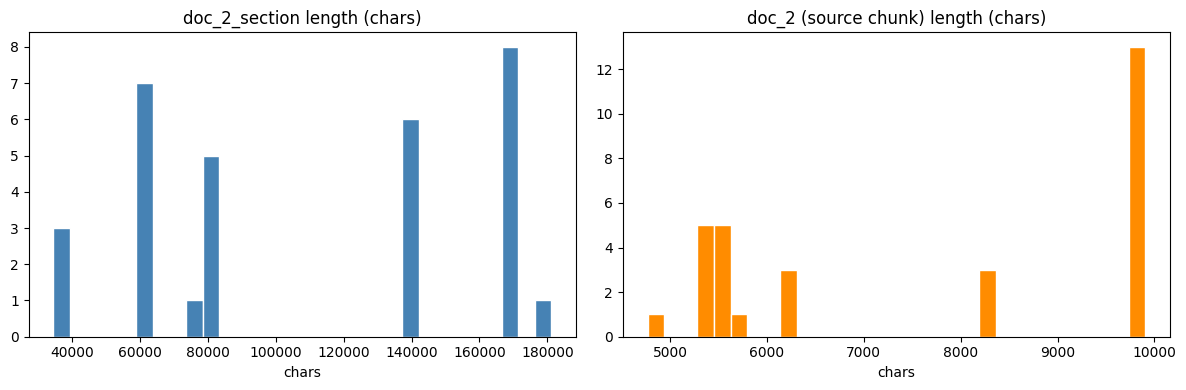

doc_2 exact match in section: 31/31 (100.0%)
doc_2 fuzzy match (first 150 chars): 31/31 (100.0%)


In [4]:
# doc_2 sizes vs section sizes
doc2_lengths = [len(r['doc_2']) for r in valid]
sec_lengths_per_record = [len(r['doc_2_section']) for r in valid]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(sec_lengths_per_record, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('doc_2_section length (chars)')
axes[0].set_xlabel('chars')

axes[1].hist(doc2_lengths, bins=30, color='darkorange', edgecolor='white')
axes[1].set_title('doc_2 (source chunk) length (chars)')
axes[1].set_xlabel('chars')

plt.tight_layout()
plt.show()

# Coverage sanity check: is doc_2 a substring of doc_2_section?
exact_hits = sum(1 for r in valid if r['doc_2'] in r['doc_2_section'])
fuzzy_hits = sum(1 for r in valid if r['doc_2'][:150].strip() in r['doc_2_section'])
print(f'doc_2 exact match in section: {exact_hits}/{len(valid)} ({exact_hits/len(valid):.1%})')
print(f'doc_2 fuzzy match (first 150 chars): {fuzzy_hits}/{len(valid)} ({fuzzy_hits/len(valid):.1%})')

## 2. Inspect structure of a single section
Print one section to understand the speaker-turn and header patterns.

In [5]:
example = valid[0]
section = example['doc_2_section']
doc2    = example['doc_2']
question = example['question']

print('=== QUESTION ===')
print(question[:400])
print()
print('=== doc_2 (first 400 chars) ===')
print(doc2[:400])
print()
print(f'=== doc_2_section ({len(section)} chars, first 1000 chars) ===')
print(section[:1000])

=== QUESTION ===
Quelles solutions M. Salis propose-t-il pour améliorer la situation des ports français selon son rapport, et comment la presse illustre-t-elle l'un de ces modèles étrangers ?

=== doc_2 (first 400 chars) ===
M. Raynal. Messieurs, je demande la permission à la Chambre d'intervenir dans ce débat. Je n'ai l'intention d'examiner que les deux points sur lesquels la discussion générale a roulé jusqu'à présent.

La grande question des chemins de fer n'a pas encore été soulevée, on ne i'a pas abordée et je ne veux pas l'aborder à mon tour. J'aime mieux prendre une situation défensive, et je réserve mon tour d

=== doc_2_section (181173 chars, first 1000 chars) ===


SUITE DE LA. DISCUSSION DU PROJETDIBLOI PORTANT FIXATION DU BUDGET GÉNÉRAL DES DÉPENSES ET RECETTES DE L'EXERCICE 1887 M. le président. L'ordre du jour appelle Ja suite de la discussion du projet de loi portant fixation du budget général des dépenses et des recettes de l'exercice i887.

La parole est à M. Louis Jou

In [6]:
import re
_SPEAKER_RE = re.compile(
    r'(?:^|\n)(M\.(?:me\.?)?\s+(?:le\s+pr[ée]sident|la\s+pr[ée]sidente|de\s+[A-ZÉÈÀÊÔÎÏÜa-z][^\n.]{1,40}|[A-ZÉÈÀÊÔ][^\n.]{1,40})\.?)\s',
    re.MULTILINE
)

speakers = [m.group(1) for m in _SPEAKER_RE.finditer(section)]
print(f'Speaker turns detected in example section: {len(speakers)}')
print('First 15 speakers:')
for s in speakers[:15]:
    print(' ', repr(s))

Speaker turns detected in example section: 88
First 15 speakers:
  'M. Louis Jourdan.'
  'M. le président.'
  'M. Prevet, rapporteur.'
  'M. Martin Nadsud disait que nous commencions'
  'M. Salis.'
  'M. le président.'
  'M. Raynal.'
  'M. Salis.'
  'M. Tony Révilion.'
  'M. Raynal.'
  'M. Raynal.'
  'M. Edouard Millaud,m~~40travaux publias.'
  'M. Raynal.'
  'M. Salis, pour le port de Liverpool, disait'
  'M. Georges Perin.'


## 3. Apply each strategy and compare segment sizes

In [7]:
strategy_outputs = {}
for name, fn in STRATEGIES.items():
    segs = fn(section)
    strategy_outputs[name] = segs
    print(f'{name:35s}  n_segs={len(segs):4d}  lens=[{min(len(s) for s in segs)}, {max(len(s) for s in segs)}]  coverage={coverage_score(segs, doc2)}')

# Also run anchor expansion manually (requires source_chunk arg)
segs_s5 = anchor_expansion(section, doc2, context_turns=2)
strategy_outputs['S5_anchor_expansion(ctx=2)'] = segs_s5
print(f'{"S5_anchor_expansion(ctx=2)":35s}  n_segs={len(segs_s5):4d}  lens=[{min(len(s) for s in segs_s5)}, {max(len(s) for s in segs_s5)}]  coverage={coverage_score(segs_s5, doc2)}')

S1_header_based                      n_segs=   1  lens=[181171, 181171]  coverage=True
S2_speaker_atomic                    n_segs=  82  lens=[40, 14661]  coverage=True
S3_speaker_window_3                  n_segs=  41  lens=[169, 22195]  coverage=True
S3_speaker_window_5                  n_segs=  21  lens=[645, 25317]  coverage=True
S4_president_mediated                n_segs=  27  lens=[131, 31853]  coverage=True
S8_chapter_vote                      n_segs=  82  lens=[28, 92157]  coverage=True
S5_anchor_expansion(ctx=2)           n_segs=   3  lens=[16929, 143445]  coverage=True


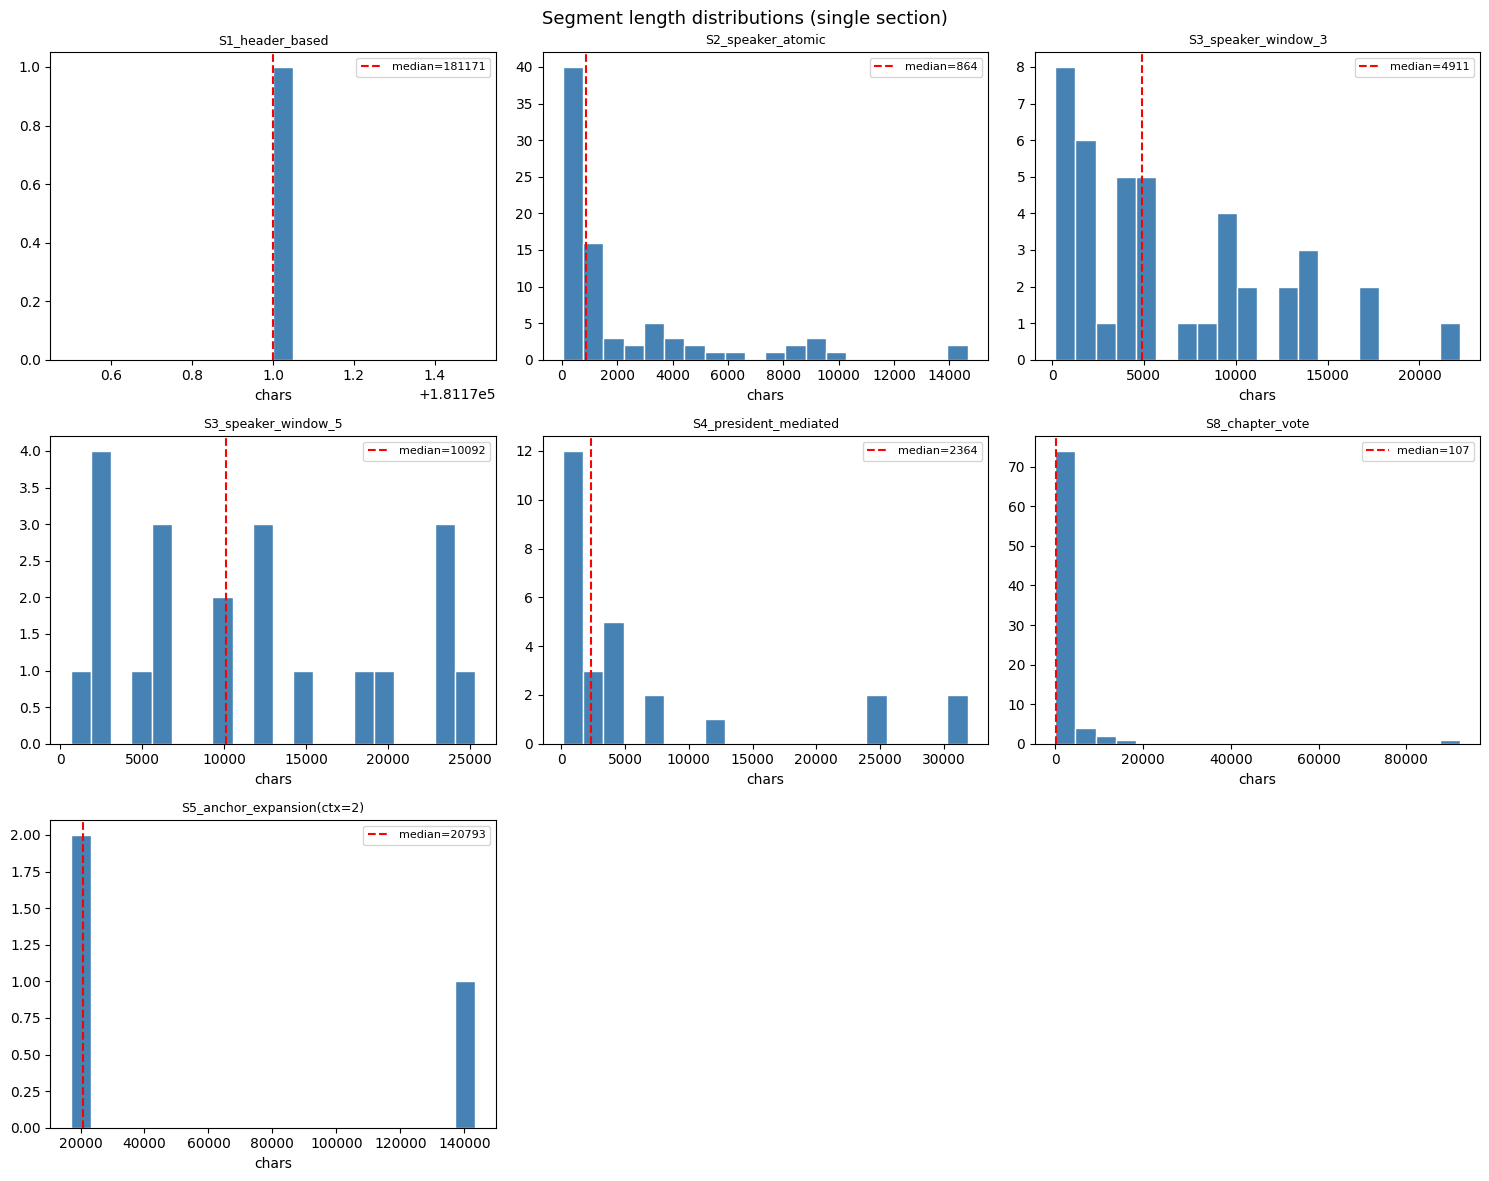

In [8]:
# Segment length distribution comparison
n_strats = len(strategy_outputs)
ncols = 3
nrows = (n_strats + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten()

for ax, (name, segs) in zip(axes, strategy_outputs.items()):
    lengths = [len(s) for s in segs]
    ax.hist(lengths, bins=20, color='steelblue', edgecolor='white')
    ax.axvline(np.median(lengths), color='red', linestyle='--', label=f'median={np.median(lengths):.0f}')
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('chars')
    ax.legend(fontsize=8)

for ax in axes[n_strats:]:
    ax.set_visible(False)

plt.suptitle('Segment length distributions (single section)', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Full dataset evaluation (coverage + size stats)
No embeddings required – deterministic strategies only.

In [9]:
# Evaluate per cluster + combined
results = {}

for label, subset in [('ALL', valid)] + [(c, [r for r in valid if r['_cluster'] == c]) for c in sorted(set(r['_cluster'] for r in valid))]:
    print(f'\n===== {label} ({len(subset)} records) =====')
    res = compare_strategies(
        records=subset,
        strategies=STRATEGIES,
        section_key='doc_2_section',
        source_key='doc_2',
        question_key='question',
        embed_fn=None,
        verbose=True,
    )
    results[label] = res
    print_summary_table(res)

# Keep combined results for downstream cells
results_all = results['ALL']


===== ALL (31 records) =====
Evaluating 6 strategies on 31 records.
  → S1_header_based ... coverage=100.00%, avg_segs=1.0, median_chars=79245
  → S2_speaker_atomic ... coverage=100.00%, avg_segs=53.6, median_chars=728
  → S3_speaker_window_3 ... coverage=100.00%, avg_segs=27.2, median_chars=3738
  → S3_speaker_window_5 ... coverage=100.00%, avg_segs=13.9, median_chars=6572
  → S4_president_mediated ... coverage=100.00%, avg_segs=14.2, median_chars=1852
  → S8_chapter_vote ... coverage=100.00%, avg_segs=22.3, median_chars=114
Strategy               avg_n_segments coverage_rate    size_count      size_max     size_mean   size_median      size_min      size_p25      size_p75      size_std
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
S1_header_based                     1         1.000            31    181171.000    109356.742     79245.000     34538.000     60521.000    

In [10]:
# Anchor expansion: evaluate per-record (needs doc_2 per call)
from segmentation_strategies.evaluate import coverage_score, size_distribution

for ctx in [0, 1, 2, 3]:
    covered = 0
    all_segs = []
    for r in valid:
        segs = anchor_expansion(r['doc_2_section'], r['doc_2'], context_turns=ctx)
        all_segs.extend(segs)
        if coverage_score(segs, r['doc_2']):
            covered += 1
    stats = size_distribution(all_segs)
    print(f'S5 ctx={ctx}: coverage={covered/len(valid):.2%}  avg_segs={len(all_segs)/len(valid):.1f}  median_chars={stats["median"]:.0f}')

S5 ctx=0: coverage=100.00%  avg_segs=3.0  median_chars=18173
S5 ctx=1: coverage=100.00%  avg_segs=3.0  median_chars=18750
S5 ctx=2: coverage=100.00%  avg_segs=3.0  median_chars=28125
S5 ctx=3: coverage=100.00%  avg_segs=3.0  median_chars=25912


## 5. Summary bar charts

In [11]:
df_results = pd.DataFrame(results_all).T
df_results.index.name = 'strategy'
df_results

,coverage_rate,avg_n_segments,size_count,size_mean,size_median,size_std,size_min,size_max,size_p25,size_p75
strategy,,,,,,,,,,
S1_header_based,1.0,1.000000,31.0,109356.741935,79245.0,50948.301555,34538.0,181171.0,60521.0,170928.00
S2_speaker_atomic,1.0,53.645161,1663.0,2036.557426,728.0,3191.857993,28.0,26014.0,168.5,2498.00
S3_speaker_window_3,1.0,27.161290,842.0,5945.570071,3737.5,6285.913944,169.0,40265.0,1434.0,8903.00
S3_speaker_window_5,1.0,13.870968,430.0,9813.858140,6572.0,9046.423729,588.0,44284.0,2708.0,13203.25
S4_president_mediated,1.0,14.225806,441.0,7685.349206,1852.0,11768.381044,58.0,50919.0,559.0,8715.00
S8_chapter_vote,1.0,22.290323,691.0,4905.564399,114.0,12868.839505,28.0,92157.0,82.0,1154.00


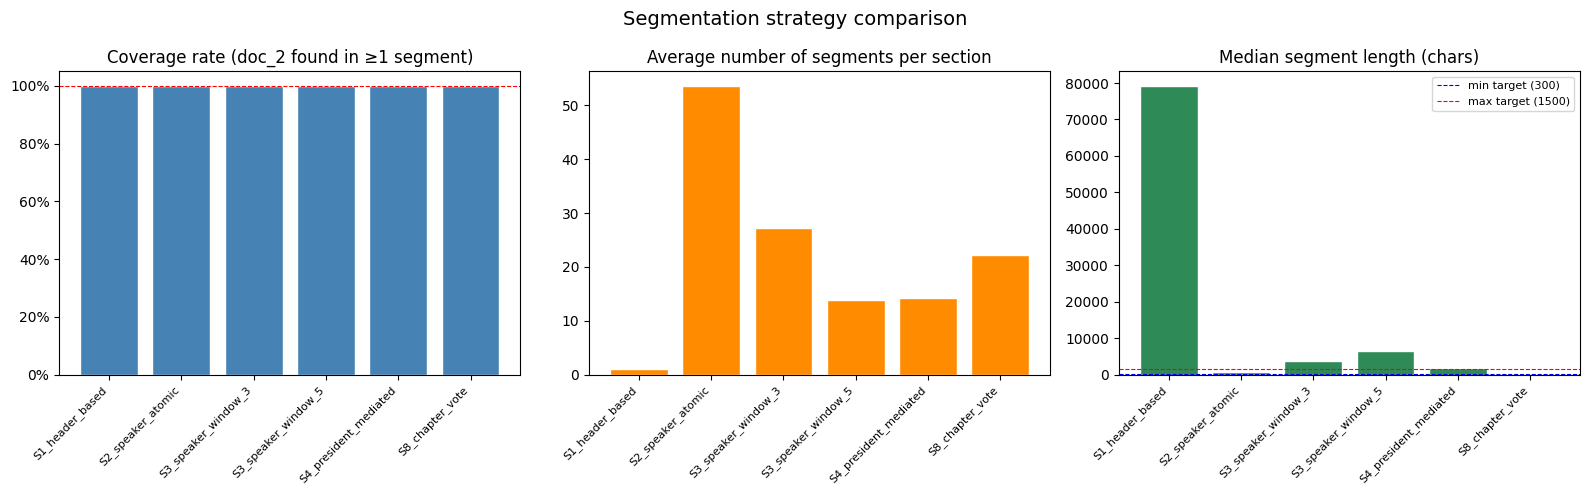

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

names = list(df_results.index)
x = np.arange(len(names))

# Coverage
cov = df_results['coverage_rate'].values
axes[0].bar(x, cov, color='steelblue', edgecolor='white')
axes[0].set_xticks(x); axes[0].set_xticklabels(names, rotation=45, ha='right', fontsize=8)
axes[0].set_ylim(0, 1.05)
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[0].set_title('Coverage rate (doc_2 found in ≥1 segment)')
axes[0].axhline(1.0, color='red', linestyle='--', linewidth=0.8)

# Avg number of segments
n_segs = df_results['avg_n_segments'].values
axes[1].bar(x, n_segs, color='darkorange', edgecolor='white')
axes[1].set_xticks(x); axes[1].set_xticklabels(names, rotation=45, ha='right', fontsize=8)
axes[1].set_title('Average number of segments per section')

# Median segment length
med_chars = df_results['size_median'].values
axes[2].bar(x, med_chars, color='seagreen', edgecolor='white')
axes[2].set_xticks(x); axes[2].set_xticklabels(names, rotation=45, ha='right', fontsize=8)
axes[2].axhline(300, color='blue', linestyle='--', linewidth=0.8, label='min target (300)')
axes[2].axhline(1500, color='red', linestyle='--', linewidth=0.8, label='max target (1500)')
axes[2].legend(fontsize=8)
axes[2].set_title('Median segment length (chars)')

plt.suptitle('Segmentation strategy comparison', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Qualitative inspection – side-by-side segments for one record

In [13]:
# Choose a record with a non-trivial section
example = max(valid, key=lambda r: len(r.get('doc_2_section') or ''))
section = example['doc_2_section']
doc2    = example['doc_2']
q       = example['question']

print('Question:', q[:300])
print(f'Section length: {len(section)} chars  (cluster: {example.get("_cluster", "?")})')
print()

strats_to_show = {**STRATEGIES, 'S5_anchor(ctx=1)': None}
for name, fn in strats_to_show.items():
    if fn is not None:
        segs = fn(section)
    else:
        segs = anchor_expansion(section, doc2, context_turns=1)
    covered = coverage_score(segs, doc2)
    sizes = [len(s) for s in segs]

    print(f'--- {name} ---  n={len(segs)}  covered={covered}  sizes={sizes[:6]}'
          + ('...' if len(sizes) > 6 else ''))
    # Show the segment that contains doc_2
    for i, s in enumerate(segs):
        if doc2[:80].strip() in s or doc2[:80].strip()[:50] in s:
            print(f'  Gold segment #{i} (first 300 chars):')
            print(f'  {repr(s[:300])}')
            break
    print()

Question: Quelles solutions M. Salis propose-t-il pour améliorer la situation des ports français selon son rapport, et comment la presse illustre-t-elle l'un de ces modèles étrangers ?
Section length: 181173 chars  (cluster: cluster_9)

--- S1_header_based ---  n=1  covered=True  sizes=[181171]
  Gold segment #0 (first 300 chars):
  "SUITE DE LA. DISCUSSION DU PROJETDIBLOI PORTANT FIXATION DU BUDGET GÉNÉRAL DES DÉPENSES ET RECETTES DE L'EXERCICE 1887 M. le président. L'ordre du jour appelle Ja suite de la discussion du projet de loi portant fixation du budget général des dépenses et des recettes de l'exercice i887.\n\nLa parole es"

--- S2_speaker_atomic ---  n=82  covered=True  sizes=[14182, 1398, 1345, 8341, 43, 2008]...
  Gold segment #5 (first 300 chars):
  "M. Raynal. Messieurs, je demande la permission à la Chambre d'intervenir dans ce débat. Je n'ai l'intention d'examiner que les deux points sur lesquels la discussion générale a roulé jusqu'à présent.\n\nLa grande question des c

## 7. Retrieval simulation (requires embedding API)

Set `USE_EMBEDDINGS = True` and provide a Cohere API key (or use sentence-transformers locally).

In [33]:
valid[0]

{'question': "Quelles solutions M. Salis propose-t-il pour améliorer la situation des ports français selon son rapport, et comment la presse illustre-t-elle l'un de ces modèles étrangers ?",
 'source_1': 'Le Gaulois',
 'id_1': '18870205',
 'doc_1': 'CHAMBRE DES DÉPUTÉS\nI te» Travaux publics |-\' Le calme a succédé à l\'orage ; les Cou t loirs sont déserts .En séance, un député de la Lozère demande une ligne de che min de fer pour son département. Il ne \' réussit pas à intéresser son auditoire, même lorsqu\'il, déclare que son chemin ; de fer est essentiellement stratégique. a On sait, depuis longtemps, que toutes les lignés à faire sont stratégiques. M. Raynal défend les ponts et chaus sées-,- qui ont été attaqués dans la séance i précédente. ïi reconnaît, toutefois, qu\'il t y a quelque chose à taire pourries con ducteurs, et rappelle qu\'étant ministre, il - a été le premier à élever un de\'ces mo -1 destes fonctionnaires au rang d\'ingé nieur. Un membre facétieux demande si, après

In [18]:
doc = valid[0]['doc_2_section']
print('=== DOC ===')    
print(doc[:2000])

=== DOC ===


SUITE DE LA. DISCUSSION DU PROJETDIBLOI PORTANT FIXATION DU BUDGET GÉNÉRAL DES DÉPENSES ET RECETTES DE L'EXERCICE 1887 M. le président. L'ordre du jour appelle Ja suite de la discussion du projet de loi portant fixation du budget général des dépenses et des recettes de l'exercice i887.

La parole est à M. Louis Jourdan, dans la discussion générale du ministère des travaux publics.

M. Louis Jourdan. Messieurs, si la Chambre veut bien me le permettre, je désirerais lui présenter quelques considérations sur les travaux de construction des chemins de fer en i887. Les considérations que j'ai l'intention de lui soumettre seront très courtes, d'abord parce que je n'ai ni le talent ni l'autorité nécessaire pour les développer longuement, et ensuite parce que je sais que chacun d'entre "vous est vivement désireux d'en finir avec le budget. (Très bienltrès bien 1) C'est une pensée des plus louables à laquelle je m'associe, et je ferai tous mes efforts pour ne pas vous retarder.

E

In [32]:
STRATEGIES["S8_chapter_vote"](section=doc)[9]

'M. le président. 1 Chap. 13. — Personnel des commissaires généraux et inspecteurs de l\'exploitation commerciale des chemins de fer. 230,500 fr. »\n\nSur le chapitre 13, M. Périlller a déposé un amendement tendant i augmenter ce crédit d\'une somme de 77,000 fr., destinée au traitement de quatorze inspecteurs nouveaux, et de le porter, en conséquence, à la somme de 307,500 francs.\n\nLa parole est i M. Périllier sur la prise en considération, l\'amendement ayant été déposé au cours de la délibération.\n\nM. Périllier. J\'espère, messieurs, que de très courtes observations me suffiront pour démontrer à la Chambre le bien fondé de l\'amendement que j\'ai l\'honneur de présenter et qui tend à obtenir une surélévation de crédit sur le chapitre i3 du budget du ministère des travaux publics.\n\nCa chapitre a pour objet la fixation du traitement des inspecteurs de l\'exploitation commerciale des chemins de fer. J\'estime que le nombre de ces inspecteurs est insuffisant et mon amendement a po

In [14]:
co = cohere.Client(COHERE_API_KEY)

def embed_fn(texts):
    response = co.embed(
        texts=texts,
        model=EMBED_MODEL,
        input_type='search_document',
    )
    return response.embeddings

print('Cohere embed function ready.')


Cohere embed function ready.


In [ ]:
from segmentation_strategies.evaluate import recall_at_k, retrieval_rank


In [16]:
results_with_retrieval = compare_strategies(
    records=valid[:50],   # use a subset to limit API calls; increase as needed
    strategies=STRATEGIES,
    section_key='doc_2_section',
    source_key='doc_2',
    question_key='question',
    embed_fn=embed_fn,
    k_values=(1, 3, 5),
    verbose=True,
)

Evaluating 6 strategies on 31 records.
  → S1_header_based ... coverage=100.00%, avg_segs=1.0, median_chars=79245
  → S2_speaker_atomic ... coverage=100.00%, avg_segs=53.6, median_chars=728
  → S3_speaker_window_3 ... coverage=100.00%, avg_segs=27.2, median_chars=3738
  → S3_speaker_window_5 ... coverage=100.00%, avg_segs=13.9, median_chars=6572
  → S4_president_mediated ... coverage=100.00%, avg_segs=14.2, median_chars=1852
  → S8_chapter_vote ... coverage=100.00%, avg_segs=22.3, median_chars=114


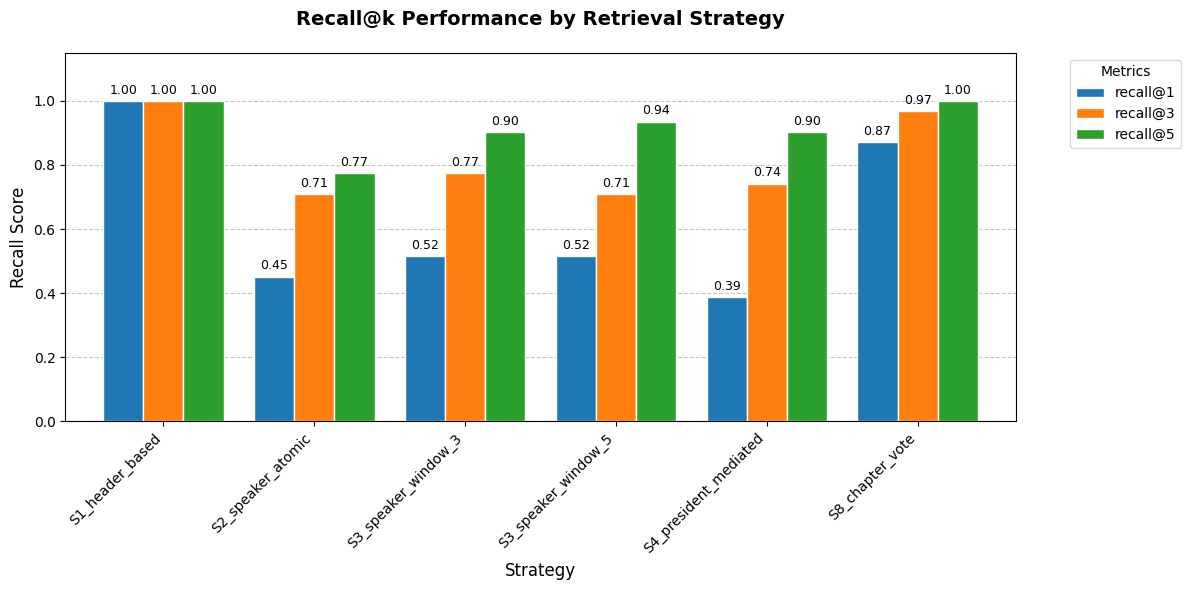

Strategy               avg_n_segments coverage_rate     mean_ranknot_found_rate      recall@1      recall@3      recall@5    size_count      size_max     size_mean   size_median      size_min      size_p25      size_p75      size_std
─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
S1_header_based                     1         1.000         0.000         0.000         1.000         1.000         1.000            31    181171.000    109356.742     79245.000     34538.000     60521.000    170928.000     50948.302
S2_speaker_atomic              53.645         1.000         2.710         0.000         0.452         0.710         0.774          1663     26014.000      2036.557       728.000        28.000       168.500      2498.000      3191.858
S3_speaker_window_3            27.161         1.000         1.29

In [17]:

df_ret = pd.DataFrame(results_with_retrieval).T
recall_cols = [c for c in df_ret.columns if c.startswith('recall@')]
df_plot = df_ret[recall_cols]


ax = df_plot.plot(kind='bar', figsize=(12, 6), width=0.8, edgecolor='white')

# 2. Add numbers on top of the bars
for container in ax.containers:
    # label_type='edge' puts text at the top
    # padding=3 gives a little breathing room between bar and text
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=9)

# 3. Enhance Aesthetics
plt.title('Recall@k Performance by Retrieval Strategy', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Recall Score', fontsize=12)
plt.xlabel('Strategy', fontsize=12)

# Add a light horizontal grid for better value tracking
ax.yaxis.grid(True, linestyle='--', alpha=0.7, zorder=0)
ax.set_axisbelow(True) # Ensure grid is behind bars

# Improve legend placement
plt.legend(title="Metrics", bbox_to_anchor=(1.05, 1), loc='upper left')

# 4. Final Layout Adjustments
plt.xticks(rotation=45, ha='right')
plt.ylim(0, df_plot.values.max() * 1.15) # Add headroom for labels
plt.tight_layout()

plt.show()

print_summary_table(results_with_retrieval)

## 8. Semantic TextTiling (S6) – optional cell

In [ ]:
if embed_fn is not None:
    section_example = valid[0]['doc_2_section']
    segs_s6 = semantic_texttiling(section_example, embed_fn, window_size=3, threshold_percentile=25)
    print(f'S6 TextTiling → {len(segs_s6)} segments')
    for i, s in enumerate(segs_s6[:5]):
        print(f'  [{i}] {len(s)} chars | {s[:120]!r}...')
else:
    print('Skipped (embed_fn is None).')

## 9. LLM-assisted thematic segmentation (S7) – optional cell

In [ ]:
USE_LLM = False   # Set to True and configure below

if USE_LLM:
    # Example using openai-compatible endpoint
    from openai import AzureOpenAI

    client = AzureOpenAI(
        api_key=os.environ['AZURE_OPENAI_KEY'],
        azure_endpoint=os.environ['AZURE_OPENAI_ENDPOINT'],
        api_version='2024-02-01',
    )

    def llm_fn(prompt: str) -> str:
        resp = client.chat.completions.create(
            model='gpt-4o-mini',
            messages=[{'role': 'user', 'content': prompt}],
            temperature=0,
        )
        return resp.choices[0].message.content

    section_example = valid[0]['doc_2_section']
    segs_s7 = llm_thematic(section_example, llm_fn)
    print(f'S7 LLM → {len(segs_s7)} segments')
    for i, s in enumerate(segs_s7):
        print(f'  [{i}] {len(s)} chars | {s[:120]!r}...')
else:
    print('LLM segmentation disabled (USE_LLM=False).')

## 10. Conclusions (clusters 9 & 16)

All strategies achieve **100 % coverage** after the preamble-absorption fix.

### Deterministic results (no embeddings)

| Strategy | Coverage | Avg segs (c9) | Median chars (c9) | Avg segs (c16) | Median chars (c16) |
|---|---:|---:|---:|---:|---:|
| S1 header | 100 % | 1.0 | 79 245 | 1.0 | 170 928 |
| S2 atomic | 100 % | 50.3 | 623 | 61.9 | 955 |
| S3 window-3 | 100 % | 25.4 | 3 181 | 31.4 | 5 525 |
| S3 window-5 | 100 % | 12.9 | 5 325 | 16.2 | 9 404 |
| S4 president | 100 % | 12.2 | 1 492 | 19.2 | 2 410 |
| S5 anchor ctx=0 | 100 % | 3.0 | 15 845 | 3.0 | ~16 000 |
| S5 anchor ctx=1 | 100 % | 3.0 | 18 750 | 3.0 | ~18 750 |
| S8 chapter-vote | 100 % | 16.0 | 126 | 37.6 | 105 |

### Key findings

1. **S3 (window-3)** is the best general-purpose strategy: good granularity (~3–5.5k median), 100 % coverage, and enough context for multi-turn reasoning.
2. **S8 (chapter-vote)** is highly bimodal: many ~100-char vote-confirmation lines + a few large discussion blocks. Useful as a **first-pass splitter** before applying S3 on the large segments.
3. **S5 (anchor)** always achieves 100 % coverage by design, but produces very few, very large segments. Best for constructing RAG gold labels.
4. **S4 (president-mediated)** offers a good intermediate tier (~1.5–2.4k median) aligning with official topic hand-offs.
5. **S1 (header)** is practically useless: most sections have only one top-level header.

### Question categories observed (clusters 9 & 16)

| Category | Description |
|---|---|
| Argument extraction | "What argument does M. X use to support Y?" |
| Position comparison | "How does M. X distinguish A from B?" |
| Press reaction | "How does the press comment/report on X?" |
| Press tone/critique | "What tone/irony/criticism does the press adopt?" |
| Legislative outcome | "What is the result of the vote on X?" |
| Reform context | "What broader reform does M. X invoke?" |

### Recommended strategy

**Primary**: S3 (window-3) for corpus-wide chunking.  
**Gold labels**: S5 (anchor, ctx=1) for retrieval evaluation ground truth.  
**Budget debates**: S8 → S3 two-pass for sections with dense chapter votes.

See `scripts/segmentation_strategies/README.md` for full documentation.